----------------------------------------------------
변경점

soft labeling 추가

label_mode='segment_max'
target_steps=100,

positive_class_weight=7.0,
near_fall_class_weight=3.0,

channels=v28.parse_int_list('64,64,128,128,256'),
dilations=v28.parse_int_list('1,2,4,8,16'),

In [7]:
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from IPython.display import display
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score

# --- 1. 환경 설정 및 드라이브 마운트 ---
IN_COLAB = 'COLAB_RELEASE_TAG' in os.environ
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
MANUAL_PROJECT_ROOT = ''

PROJECT_ROOT_CANDIDATES = [
    '/content/drive/MyDrive/Graduate-Project/Falling-Model-Development',
    '/content/drive/MyDrive/졸업 과제/Falling-Detection-Development',
    '/content/Falling-Model-Development',
    str(Path.cwd()),
]

candidate_paths = [MANUAL_PROJECT_ROOT] + PROJECT_ROOT_CANDIDATES if MANUAL_PROJECT_ROOT else PROJECT_ROOT_CANDIDATES

PROJECT_ROOT = None
for candidate in candidate_paths:
    path = Path(candidate)
    if (path / 'scripts').exists() and (path / 'dataset').exists():
        PROJECT_ROOT = path.resolve()
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError('프로젝트 루트를 찾지 못했습니다. MANUAL_PROJECT_ROOT를 직접 지정하거나 경로를 확인하세요.')

DATA_ROOT = PROJECT_ROOT / 'dataset'
ARTIFACT_ROOT = PROJECT_ROOT / 'artifacts' / 'tcn_v28_notebook'
ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)

os.environ['PROJECT_ROOT'] = str(PROJECT_ROOT)
os.environ['DATA_ROOT'] = str(DATA_ROOT)
os.environ['ARTIFACT_ROOT'] = str(ARTIFACT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f'PROJECT_ROOT  : {PROJECT_ROOT}')
print(f'DATA_ROOT     : {DATA_ROOT}')
print(f'ARTIFACT_ROOT : {ARTIFACT_ROOT}')

PROJECT_ROOT  : /content/drive/.shortcut-targets-by-id/1sPM3m7rEt6UUnWt9ulH3rzFYhguMJMUY/졸업 과제/Falling-Detection-Development
DATA_ROOT     : /content/drive/.shortcut-targets-by-id/1sPM3m7rEt6UUnWt9ulH3rzFYhguMJMUY/졸업 과제/Falling-Detection-Development/dataset
ARTIFACT_ROOT : /content/drive/.shortcut-targets-by-id/1sPM3m7rEt6UUnWt9ulH3rzFYhguMJMUY/졸업 과제/Falling-Detection-Development/artifacts/tcn_v28_notebook


In [9]:
# --- 2. 모듈 임포트  ---
import scripts.train_tcn_v28 as v28
from scripts.train_tcn_v2 import (
    build_tcn_v2_model, compile_model, load_source_frame,
    set_seed, log, normalize_splits, evaluate_model,
    export_tflite_artifacts, save_visualization_artifacts, save_run_metadata
)
from scripts.train_tcn_v25 import parse_int_list

In [10]:
# --- 3. 유틸리티 함수 ---
def plot_history(history):
    history_df = pd.DataFrame(history.history)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    history_df[['loss', 'val_loss']].plot(ax=axes[0], marker='o')
    axes[0].set_title('Loss Curve')
    axes[0].grid(True, alpha=0.3)
    metric_cols = [col for col in ['accuracy', 'val_accuracy'] if col in history_df.columns]
    history_df[metric_cols].plot(ax=axes[1], marker='o')
    axes[1].set_title('Accuracy Curve')
    axes[1].grid(True, alpha=0.3)
    plt.show()

def plot_confusion(metrics_dict, split_name):
    cm = np.array(metrics_dict['confusion_matrix'])
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'{split_name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

def metrics_table(metrics_dict):
    rows = []
    for name, m in metrics_dict.items():
        rows.append({
            'split': name,
            'accuracy': m.get('accuracy', 0),
            'precision': m.get('precision', 0),
            'recall': m.get('recall', 0),
            'macro_f1': m.get('macro_f1', 0),
        })
    return pd.DataFrame(rows)

def apply_consecutive_rule(binary_pred, min_consecutive=1):
    binary_pred = np.asarray(binary_pred, dtype=np.int32)
    if min_consecutive <= 1: return binary_pred
    filtered = np.zeros_like(binary_pred)
    start = None
    for idx, value in enumerate(binary_pred):
        if value == 1 and start is None: start = idx
        elif value == 0 and start is not None:
            if idx - start >= min_consecutive: filtered[start:idx] = 1
            start = None
    if start is not None and len(binary_pred) - start >= min_consecutive:
        filtered[start:] = 1
    return filtered

def evaluate_threshold_predictions(y_true, positive_scores, threshold, min_consecutive=1):
    raw_pred = (np.asarray(positive_scores) >= threshold).astype(np.int32)
    y_true_binary = (np.asarray(y_true) == 1).astype(np.int32)
    pred = apply_consecutive_rule(raw_pred, min_consecutive)
    return {
        'accuracy': float((pred == y_true_binary).mean()),
        'precision': float(precision_score(y_true_binary, pred, zero_division=0)),
        'recall': float(recall_score(y_true_binary, pred, zero_division=0)),
        'macro_f1': float(f1_score(y_true_binary, pred, average='macro', zero_division=0)),
        'confusion_matrix': confusion_matrix(y_true_binary, pred, labels=[0, 1]).tolist(),
        'classification_report': classification_report(y_true_binary, pred, digits=4, zero_division=0)
    }

def threshold_sweep(y_true, positive_scores, thresholds, min_consecutive=1):
    rows = []
    for th in thresholds:
        m = evaluate_threshold_predictions(y_true, positive_scores, th, min_consecutive)
        rows.append({'threshold': th, **m})
    return pd.DataFrame(rows)

def plot_video_probability_examples(model, config, feature_cols, mean, std, video_ids, threshold=0.5, min_consecutive=3):
    for vid in video_ids:
        df_all, _ = load_source_frame(config)
        df_vid = df_all[df_all['video_id'] == vid].sort_values(['time_sec', 'frame'])
        vals = df_vid[feature_cols].to_numpy(dtype=np.float32)
        if len(vals) < config.target_steps: continue
        wins = [vals[i : i + config.target_steps] for i in range(len(vals) - config.target_steps + 1)]
        norm_wins = (np.array(wins) - mean) / std
        preds = model.predict(norm_wins, verbose=0)
        probs = preds[:, 1]
        times = df_vid['time_sec'].to_numpy()[config.target_steps - 1:]
        gt = (df_vid['label'].to_numpy()[config.target_steps - 1:] == 1).astype(int)
        alarm = apply_consecutive_rule((probs >= threshold).astype(np.int32), min_consecutive)
        plt.figure(figsize=(12, 3))
        plt.plot(times, probs, color='red', label='Fall Prob')
        plt.fill_between(times, gt, alpha=0.2, color='gray', label='GT (Fall)')
        plt.fill_between(times, alarm, alpha=0.2, color='orange', label='Alarm')
        plt.axhline(threshold, color='blue', linestyle='--', label=f'Th={threshold:.2f}')
        plt.ylim(-0.05, 1.05); plt.title(f'Video ID: {vid}'); plt.legend(loc='upper right'); plt.grid(alpha=0.3)
        plt.show()

In [11]:
# --- 4. 학습 설정 (Config) ---
config = v28.TcnV28TrainConfig(
    input_format='csv',
    csv_path=str(DATA_ROOT / 'final_dataset.csv'),
    sqlite_path=str(DATA_ROOT / 'final_dataset.sqlite'),
    sqlite_table='fall_frames',
    output_dir=str(ARTIFACT_ROOT),
    monitor_start_sec=4.0, monitor_end_sec=10.0, target_steps=100,
    label_mode='segment_max', batch_size=128, epochs=30, warmup_epochs=5,
    learning_rate=1e-3, random_state=42, kernel_size=3, dropout_rate=0.2,
    dilations=parse_int_list('1,2,4,8,16'), channels=parse_int_list('64,64,128,128,256'),
    export_tflite=False, train_positive_stride=1, train_near_fall_stride=2,
    train_negative_stride=10, eval_stride=1,
    fp_threshold=0.90,
    positive_class_weight=7.0,
    near_fall_class_weight=3.0
)

In [12]:
# --- 5. 실행 파이프라인 ---
set_seed(config.random_state)
df_source, feature_cols = load_source_frame(config)

# Stage 1: Warmup
warmup_model, mean, std = v28.run_warmup_pipeline(df_source, feature_cols, config)

# Stage 2: Mining
updated_df = v28.auto_label_hard_negatives(
    warmup_model, df_source, feature_cols, config, mean, std, threshold=0.90
)

# Stage 3: Final Training
model, history, train_data, val_data, test_data = v28.run_final_training_pipeline(
    updated_df, feature_cols, config, mean, std
)

x_train, y_train, g_train = train_data
x_val, y_val, g_val = val_data
x_test, y_test, g_test = test_data

[2026-04-13 15:37:34] loading csv source from /content/drive/.shortcut-targets-by-id/1sPM3m7rEt6UUnWt9ulH3rzFYhguMJMUY/졸업 과제/Falling-Detection-Development/dataset/final_dataset.csv
[2026-04-13 15:39:07] csv rows loaded=4093620 feature_count=55
[2026-04-13 15:39:07] >>> stage 1: warmup training
Epoch 1/5
1732/1732 ━━━━━━━━━━━━━━━━━━━━ 67s 25ms/step - accuracy: 0.9619 - loss: 0.2038 - pr_auc: 0.9861 - precision: 0.9616 - recall: 0.9993 - val_accuracy: 0.8413 - val_loss: 0.5374 - val_pr_auc: 0.9495 - val_precision: 0.8092 - val_recall: 0.9981
Epoch 2/5
1732/1732 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9681 - loss: 0.1575 - pr_auc: 0.9914 - precision: 0.9674 - recall: 0.9997 - val_accuracy: 0.8587 - val_loss: 0.4530 - val_pr_auc: 0.9592 - val_precision: 0.8282 - val_recall: 0.9952
Epoch 3/5
1732/1732 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9710 - loss: 0.1424 - pr_auc: 0.9921 - precision: 0.9701 - recall: 0.9998 - val_accuracy: 0.8670 - val_loss: 0.4513 - val_pr_auc: 0.96

Mining Hard Negatives:   0%|          | 0/20380 [00:00<?, ?it/s]

[2026-04-13 16:16:50] Auto-labeling done
[2026-04-13 16:16:50] >>> stage 2: final training (3-class weighted)
[2026-04-13 16:17:21] train windows=238867 videos=14266 positives=207571 near_falls=23918 negatives=7378
[2026-04-13 16:17:21] val windows=66156 videos=3057 positives=44270 near_falls=10580 negatives=11306
[2026-04-13 16:17:21] test windows=66166 videos=3057 positives=44061 near_falls=11219 negatives=10886
Epoch 1/30
1867/1867 ━━━━━━━━━━━━━━━━━━━━ 57s 21ms/step - accuracy: 0.8999 - loss: 0.8923 - val_accuracy: 0.8208 - val_loss: 0.4453 - learning_rate: 0.0010
Epoch 2/30
1867/1867 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9184 - loss: 0.6884 - val_accuracy: 0.8359 - val_loss: 0.4133 - learning_rate: 0.0010
Epoch 3/30
1867/1867 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9284 - loss: 0.5957 - val_accuracy: 0.8283 - val_loss: 0.4726 - learning_rate: 0.0010
Epoch 4/30
1867/1867 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9388 - loss: 0.5080 - val_accuracy: 0.8492 -

In [13]:
# --- 6. 후처리 및 시각화 ---
# 모델 저장
keras_path = ARTIFACT_ROOT / 'tcn_v28.keras'
model.save(keras_path)

In [14]:
# 확률 추출 (Class 1: Fall)
train_prob = model.predict(x_train, verbose=0)[:, 1]
val_prob = model.predict(x_val, verbose=0)[:, 1]
test_prob = model.predict(x_test, verbose=0)[:, 1]

In [16]:
# 임계치 최적화 (F1-score 기반)
THRESHOLD_GRID = np.linspace(0.05, 0.95, 19)
MIN_CONSECUTIVE = 3
sweep_df = threshold_sweep(y_val, val_prob, THRESHOLD_GRID, MIN_CONSECUTIVE)
selected_threshold = float(sweep_df.sort_values('macro_f1', ascending=False).iloc[0]['threshold'])

In [17]:
# 최종 평가
threshold_metrics = {
    'train': evaluate_threshold_predictions(y_train, train_prob, selected_threshold, MIN_CONSECUTIVE),
    'val': evaluate_threshold_predictions(y_val, val_prob, selected_threshold, MIN_CONSECUTIVE),
    'test': evaluate_threshold_predictions(y_test, test_prob, selected_threshold, MIN_CONSECUTIVE),
}


[v28 Final Results] Best Threshold: 0.6500 | Min Consecutive: 3


,split,accuracy,precision,recall,macro_f1
0,train,0.966693,0.973445,0.988640,0.923468
1,val,0.901868,0.901091,0.958572,0.885201
2,test,0.893510,0.892599,0.954994,0.875716


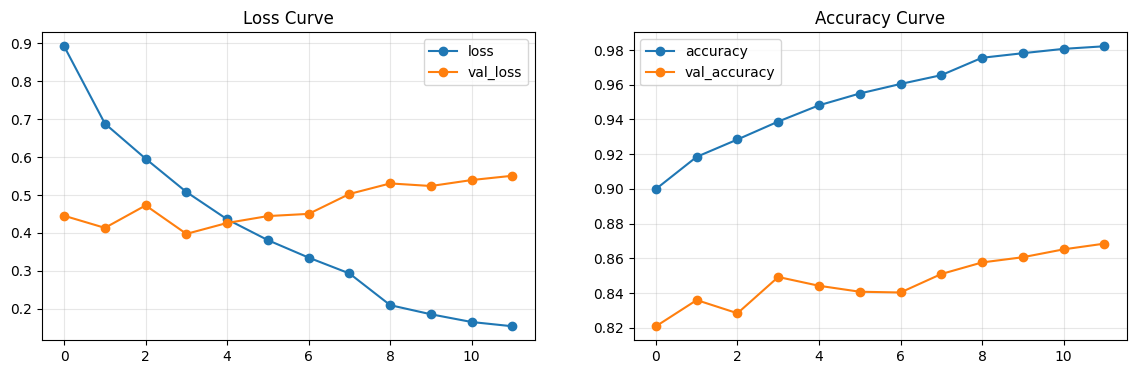

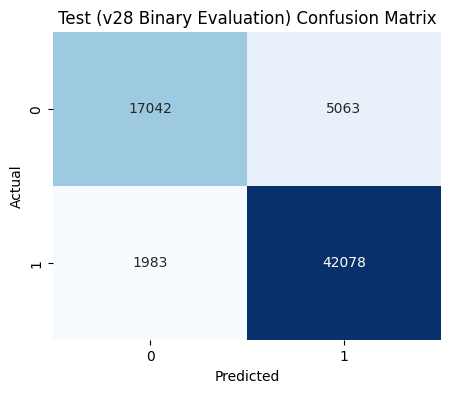

In [18]:
#리포트 출력
print(f"\n[v28 Final Results] Best Threshold: {selected_threshold:.4f} | Min Consecutive: {MIN_CONSECUTIVE}")
display(metrics_table(threshold_metrics))
plot_history(history)
plot_confusion(threshold_metrics['test'], 'Test (v28 Binary Evaluation)')

[2026-04-13 16:24:56] loading csv source from /content/drive/.shortcut-targets-by-id/1sPM3m7rEt6UUnWt9ulH3rzFYhguMJMUY/졸업 과제/Falling-Detection-Development/dataset/final_dataset.csv
[2026-04-13 16:25:52] csv rows loaded=4093620 feature_count=55


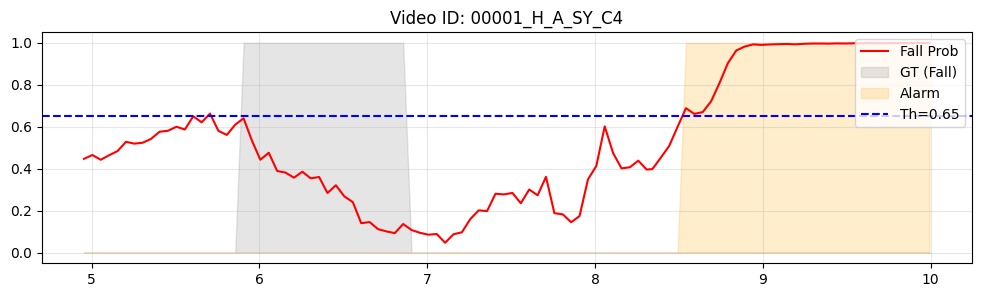

[2026-04-13 16:25:55] loading csv source from /content/drive/.shortcut-targets-by-id/1sPM3m7rEt6UUnWt9ulH3rzFYhguMJMUY/졸업 과제/Falling-Detection-Development/dataset/final_dataset.csv
[2026-04-13 16:26:52] csv rows loaded=4093620 feature_count=55


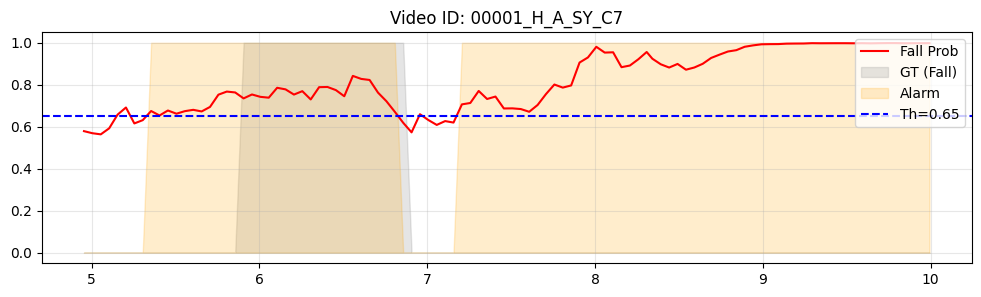

[2026-04-13 16:26:52] loading csv source from /content/drive/.shortcut-targets-by-id/1sPM3m7rEt6UUnWt9ulH3rzFYhguMJMUY/졸업 과제/Falling-Detection-Development/dataset/final_dataset.csv
[2026-04-13 16:27:47] csv rows loaded=4093620 feature_count=55


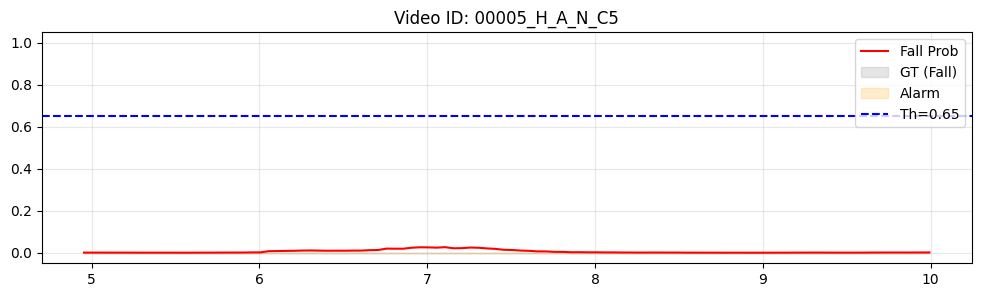

[2026-04-13 16:27:48] loading csv source from /content/drive/.shortcut-targets-by-id/1sPM3m7rEt6UUnWt9ulH3rzFYhguMJMUY/졸업 과제/Falling-Detection-Development/dataset/final_dataset.csv
[2026-04-13 16:28:44] csv rows loaded=4093620 feature_count=55


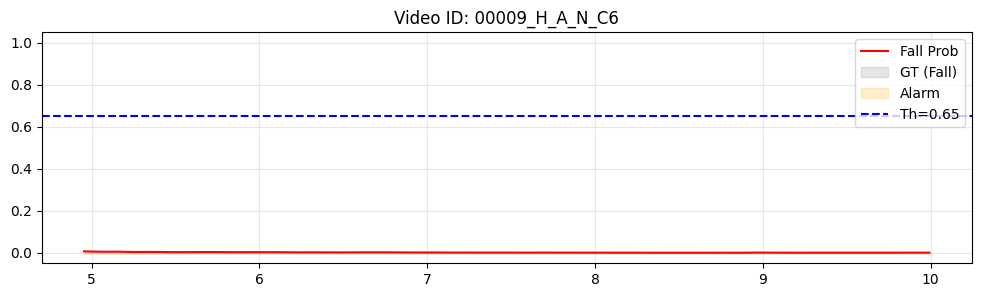

In [19]:
# 비디오 시각화 예시
test_vid_df = pd.DataFrame({'video_id': g_test, 'label': y_test})
pos_vids = test_vid_df[test_vid_df['label'] == 1]['video_id'].unique()[:2]
neg_vids = test_vid_df[test_vid_df['label'] == 0]['video_id'].unique()[:2]
plot_video_probability_examples(model, config, feature_cols, mean, std, list(pos_vids) + list(neg_vids), threshold=selected_threshold)

[2026-04-13 16:35:35] loading csv source from /content/drive/.shortcut-targets-by-id/1sPM3m7rEt6UUnWt9ulH3rzFYhguMJMUY/졸업 과제/Falling-Detection-Development/dataset/final_dataset.csv
[2026-04-13 16:36:30] csv rows loaded=4093620 feature_count=55


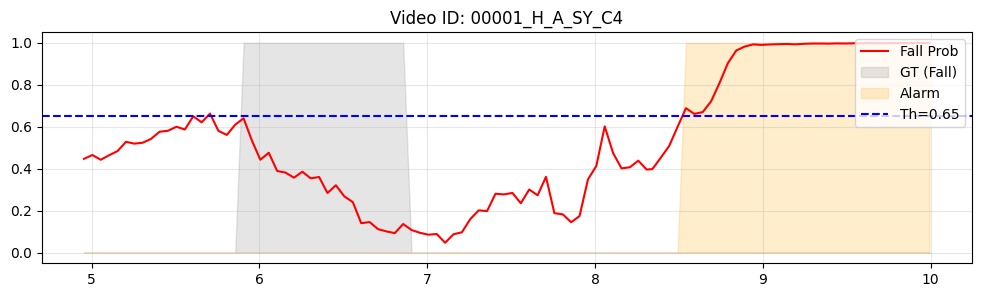

[2026-04-13 16:36:31] loading csv source from /content/drive/.shortcut-targets-by-id/1sPM3m7rEt6UUnWt9ulH3rzFYhguMJMUY/졸업 과제/Falling-Detection-Development/dataset/final_dataset.csv
[2026-04-13 16:37:27] csv rows loaded=4093620 feature_count=55


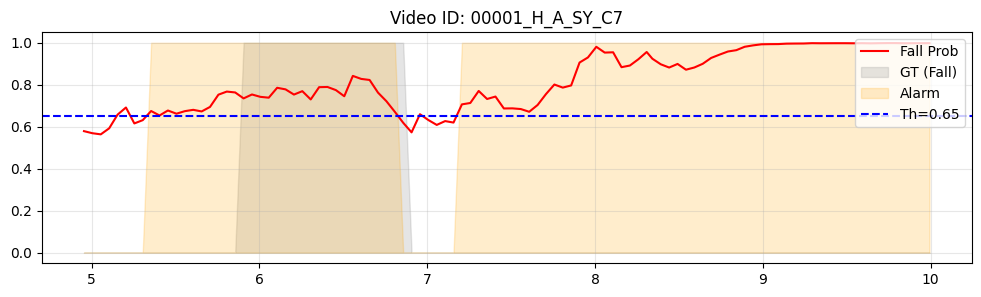

[2026-04-13 16:37:28] loading csv source from /content/drive/.shortcut-targets-by-id/1sPM3m7rEt6UUnWt9ulH3rzFYhguMJMUY/졸업 과제/Falling-Detection-Development/dataset/final_dataset.csv
[2026-04-13 16:38:23] csv rows loaded=4093620 feature_count=55


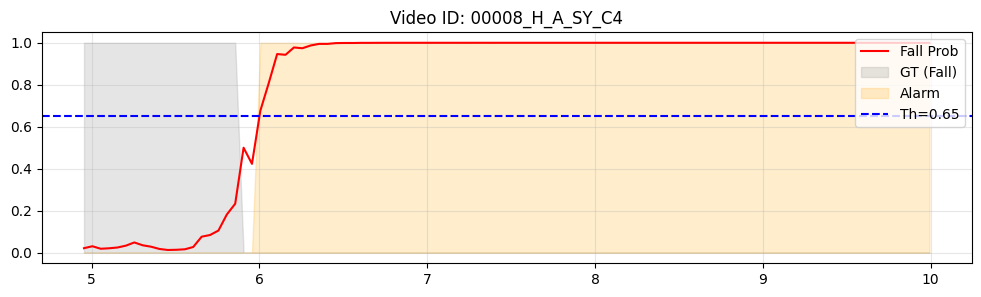

[2026-04-13 16:38:24] loading csv source from /content/drive/.shortcut-targets-by-id/1sPM3m7rEt6UUnWt9ulH3rzFYhguMJMUY/졸업 과제/Falling-Detection-Development/dataset/final_dataset.csv
[2026-04-13 16:39:20] csv rows loaded=4093620 feature_count=55


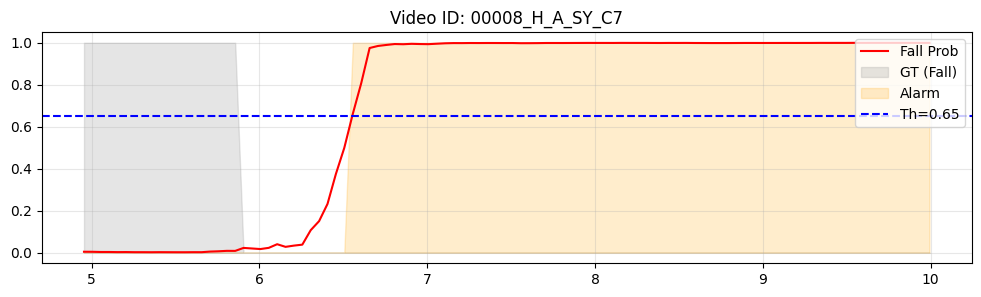

[2026-04-13 16:39:21] loading csv source from /content/drive/.shortcut-targets-by-id/1sPM3m7rEt6UUnWt9ulH3rzFYhguMJMUY/졸업 과제/Falling-Detection-Development/dataset/final_dataset.csv
[2026-04-13 16:40:17] csv rows loaded=4093620 feature_count=55


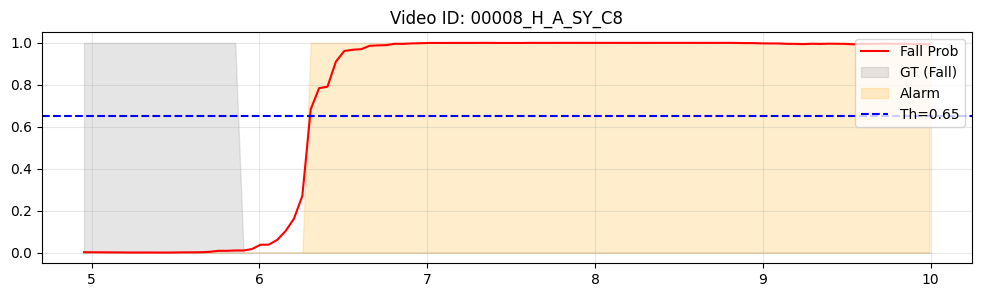

[2026-04-13 16:40:18] loading csv source from /content/drive/.shortcut-targets-by-id/1sPM3m7rEt6UUnWt9ulH3rzFYhguMJMUY/졸업 과제/Falling-Detection-Development/dataset/final_dataset.csv
[2026-04-13 16:41:15] csv rows loaded=4093620 feature_count=55


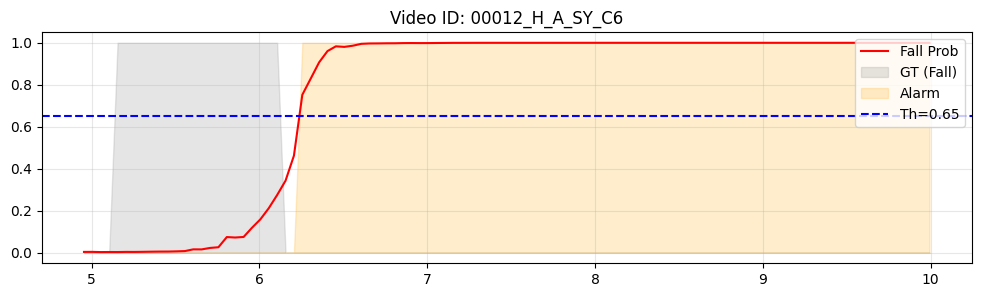

[2026-04-13 16:41:15] loading csv source from /content/drive/.shortcut-targets-by-id/1sPM3m7rEt6UUnWt9ulH3rzFYhguMJMUY/졸업 과제/Falling-Detection-Development/dataset/final_dataset.csv
[2026-04-13 16:42:11] csv rows loaded=4093620 feature_count=55


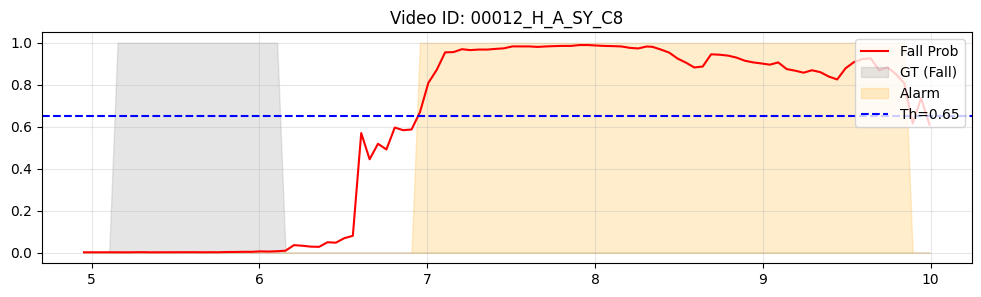

[2026-04-13 16:42:11] loading csv source from /content/drive/.shortcut-targets-by-id/1sPM3m7rEt6UUnWt9ulH3rzFYhguMJMUY/졸업 과제/Falling-Detection-Development/dataset/final_dataset.csv
[2026-04-13 16:43:08] csv rows loaded=4093620 feature_count=55


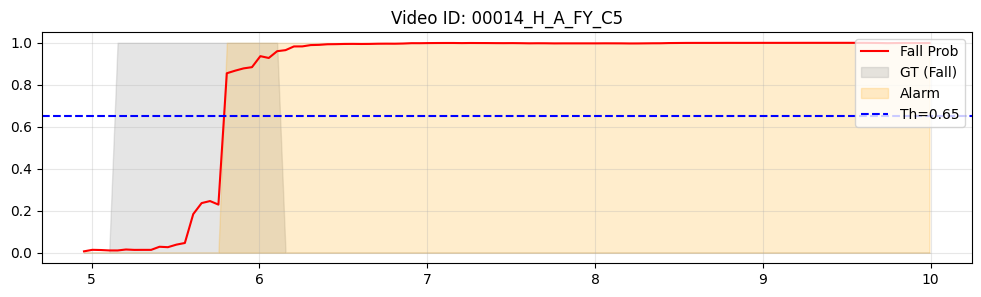

[2026-04-13 16:43:08] loading csv source from /content/drive/.shortcut-targets-by-id/1sPM3m7rEt6UUnWt9ulH3rzFYhguMJMUY/졸업 과제/Falling-Detection-Development/dataset/final_dataset.csv
[2026-04-13 16:44:03] csv rows loaded=4093620 feature_count=55


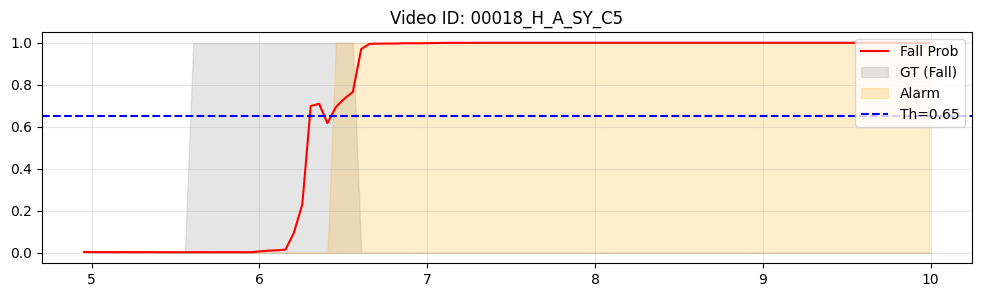

[2026-04-13 16:44:04] loading csv source from /content/drive/.shortcut-targets-by-id/1sPM3m7rEt6UUnWt9ulH3rzFYhguMJMUY/졸업 과제/Falling-Detection-Development/dataset/final_dataset.csv
[2026-04-13 16:44:59] csv rows loaded=4093620 feature_count=55


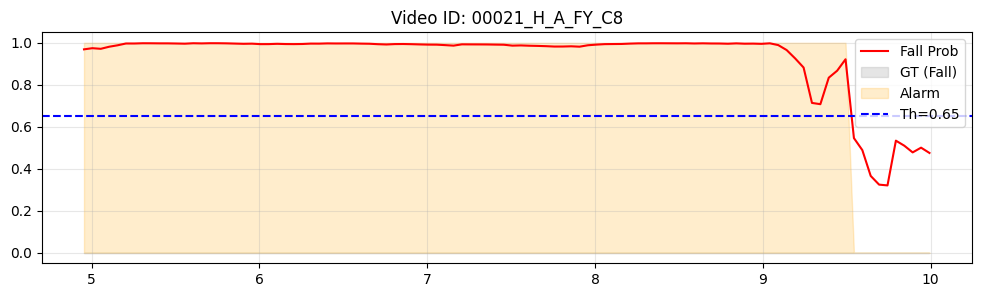

[2026-04-13 16:45:00] loading csv source from /content/drive/.shortcut-targets-by-id/1sPM3m7rEt6UUnWt9ulH3rzFYhguMJMUY/졸업 과제/Falling-Detection-Development/dataset/final_dataset.csv
[2026-04-13 16:45:56] csv rows loaded=4093620 feature_count=55


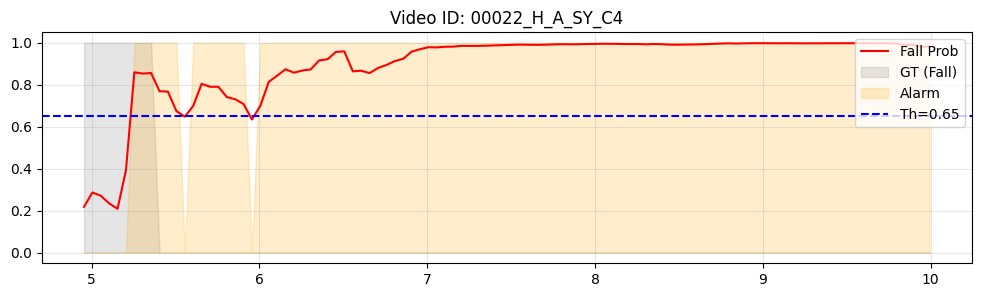

[2026-04-13 16:45:57] loading csv source from /content/drive/.shortcut-targets-by-id/1sPM3m7rEt6UUnWt9ulH3rzFYhguMJMUY/졸업 과제/Falling-Detection-Development/dataset/final_dataset.csv
[2026-04-13 16:46:52] csv rows loaded=4093620 feature_count=55


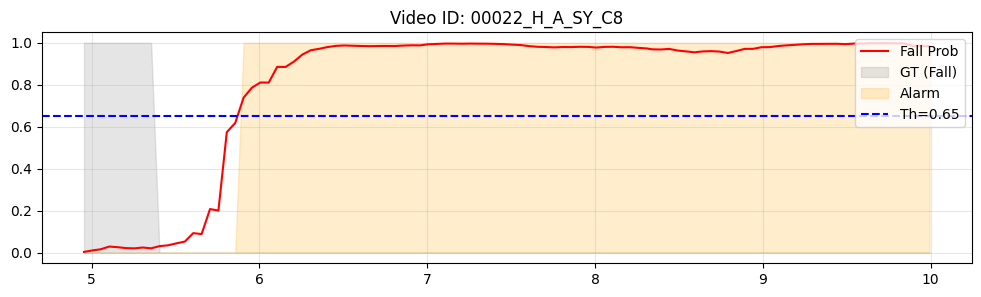

[2026-04-13 16:46:52] loading csv source from /content/drive/.shortcut-targets-by-id/1sPM3m7rEt6UUnWt9ulH3rzFYhguMJMUY/졸업 과제/Falling-Detection-Development/dataset/final_dataset.csv
[2026-04-13 16:47:49] csv rows loaded=4093620 feature_count=55


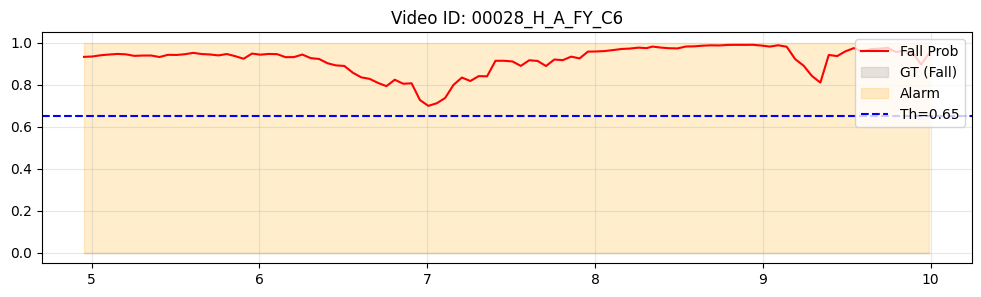

[2026-04-13 16:47:49] loading csv source from /content/drive/.shortcut-targets-by-id/1sPM3m7rEt6UUnWt9ulH3rzFYhguMJMUY/졸업 과제/Falling-Detection-Development/dataset/final_dataset.csv
[2026-04-13 16:48:44] csv rows loaded=4093620 feature_count=55


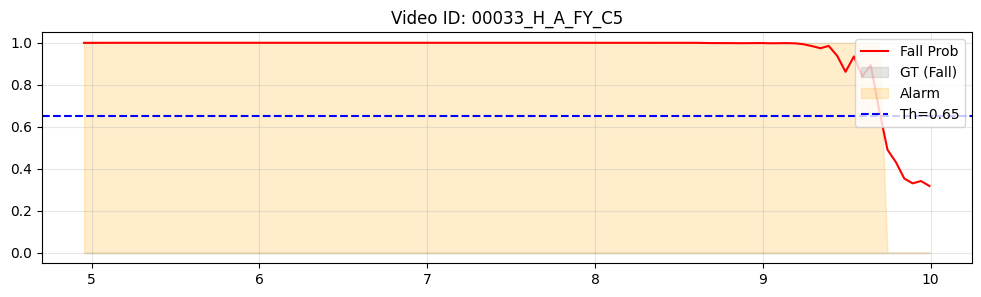

[2026-04-13 16:48:45] loading csv source from /content/drive/.shortcut-targets-by-id/1sPM3m7rEt6UUnWt9ulH3rzFYhguMJMUY/졸업 과제/Falling-Detection-Development/dataset/final_dataset.csv
[2026-04-13 16:49:41] csv rows loaded=4093620 feature_count=55


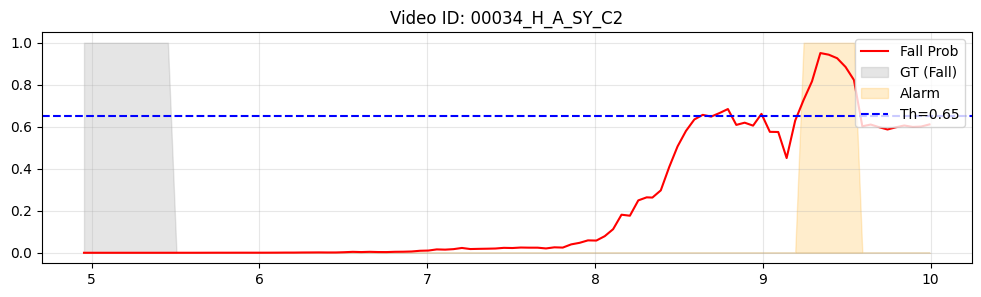

[2026-04-13 16:49:42] loading csv source from /content/drive/.shortcut-targets-by-id/1sPM3m7rEt6UUnWt9ulH3rzFYhguMJMUY/졸업 과제/Falling-Detection-Development/dataset/final_dataset.csv
[2026-04-13 16:50:39] csv rows loaded=4093620 feature_count=55


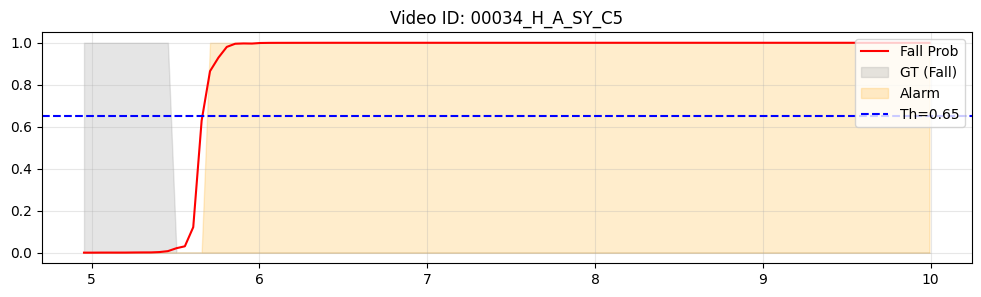

[2026-04-13 16:50:40] loading csv source from /content/drive/.shortcut-targets-by-id/1sPM3m7rEt6UUnWt9ulH3rzFYhguMJMUY/졸업 과제/Falling-Detection-Development/dataset/final_dataset.csv
[2026-04-13 16:51:34] csv rows loaded=4093620 feature_count=55


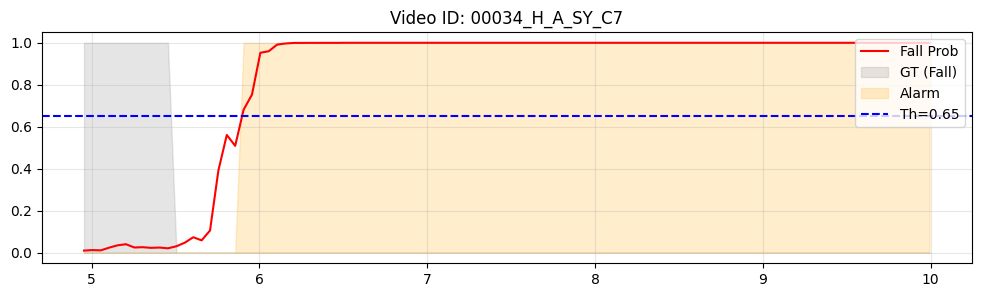

[2026-04-13 16:51:35] loading csv source from /content/drive/.shortcut-targets-by-id/1sPM3m7rEt6UUnWt9ulH3rzFYhguMJMUY/졸업 과제/Falling-Detection-Development/dataset/final_dataset.csv
[2026-04-13 16:52:30] csv rows loaded=4093620 feature_count=55


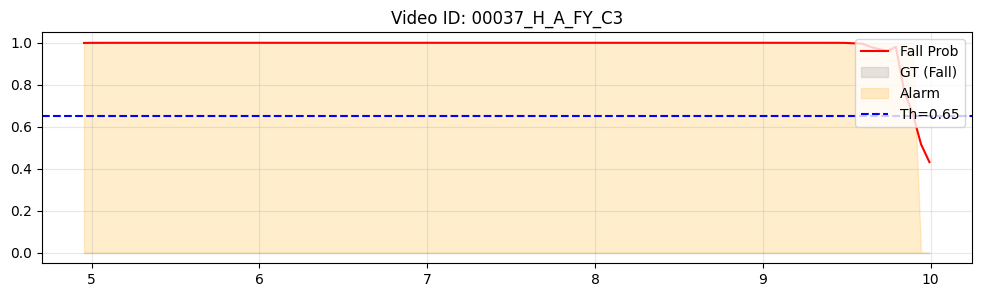

[2026-04-13 16:52:31] loading csv source from /content/drive/.shortcut-targets-by-id/1sPM3m7rEt6UUnWt9ulH3rzFYhguMJMUY/졸업 과제/Falling-Detection-Development/dataset/final_dataset.csv
[2026-04-13 16:53:27] csv rows loaded=4093620 feature_count=55


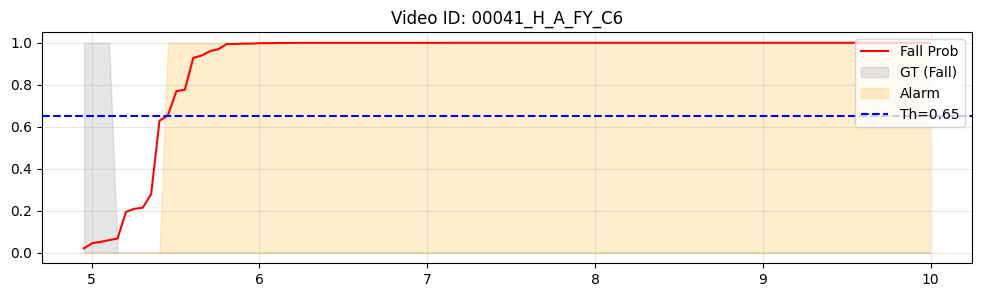

[2026-04-13 16:53:28] loading csv source from /content/drive/.shortcut-targets-by-id/1sPM3m7rEt6UUnWt9ulH3rzFYhguMJMUY/졸업 과제/Falling-Detection-Development/dataset/final_dataset.csv
[2026-04-13 16:54:23] csv rows loaded=4093620 feature_count=55


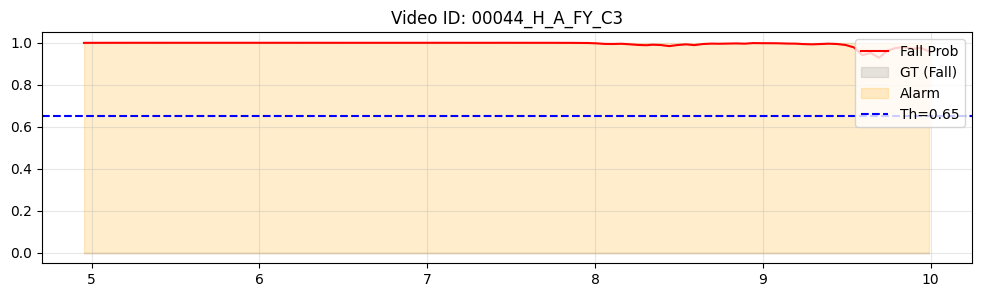

[2026-04-13 16:54:24] loading csv source from /content/drive/.shortcut-targets-by-id/1sPM3m7rEt6UUnWt9ulH3rzFYhguMJMUY/졸업 과제/Falling-Detection-Development/dataset/final_dataset.csv
[2026-04-13 16:55:21] csv rows loaded=4093620 feature_count=55


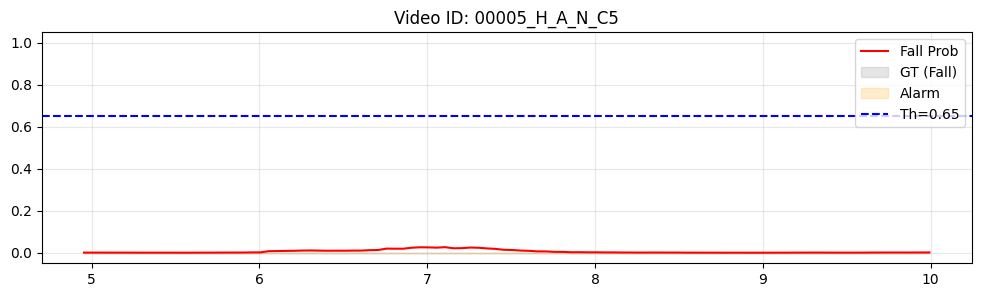

[2026-04-13 16:55:22] loading csv source from /content/drive/.shortcut-targets-by-id/1sPM3m7rEt6UUnWt9ulH3rzFYhguMJMUY/졸업 과제/Falling-Detection-Development/dataset/final_dataset.csv
[2026-04-13 16:56:17] csv rows loaded=4093620 feature_count=55


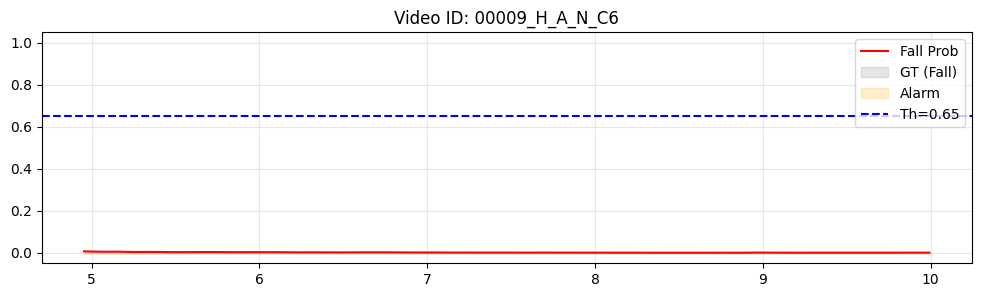

[2026-04-13 16:56:18] loading csv source from /content/drive/.shortcut-targets-by-id/1sPM3m7rEt6UUnWt9ulH3rzFYhguMJMUY/졸업 과제/Falling-Detection-Development/dataset/final_dataset.csv
[2026-04-13 16:57:14] csv rows loaded=4093620 feature_count=55


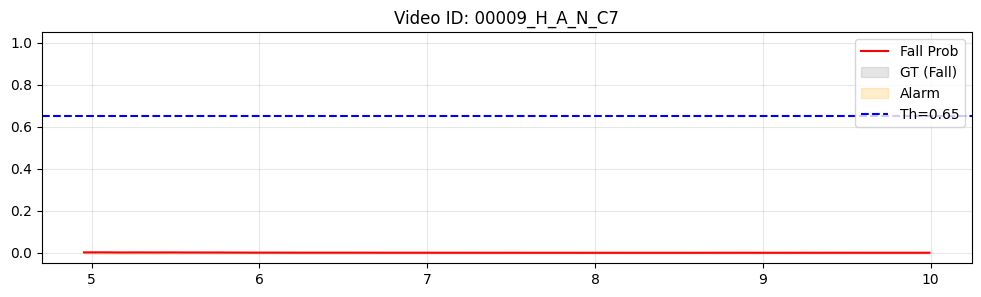

[2026-04-13 16:57:15] loading csv source from /content/drive/.shortcut-targets-by-id/1sPM3m7rEt6UUnWt9ulH3rzFYhguMJMUY/졸업 과제/Falling-Detection-Development/dataset/final_dataset.csv
[2026-04-13 16:58:11] csv rows loaded=4093620 feature_count=55


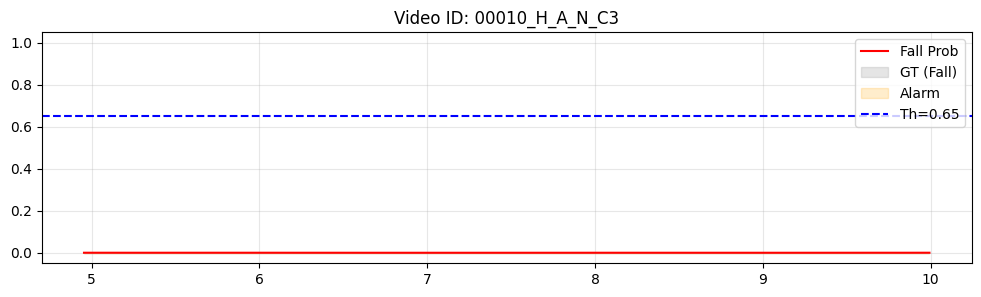

[2026-04-13 16:58:12] loading csv source from /content/drive/.shortcut-targets-by-id/1sPM3m7rEt6UUnWt9ulH3rzFYhguMJMUY/졸업 과제/Falling-Detection-Development/dataset/final_dataset.csv
[2026-04-13 16:59:08] csv rows loaded=4093620 feature_count=55


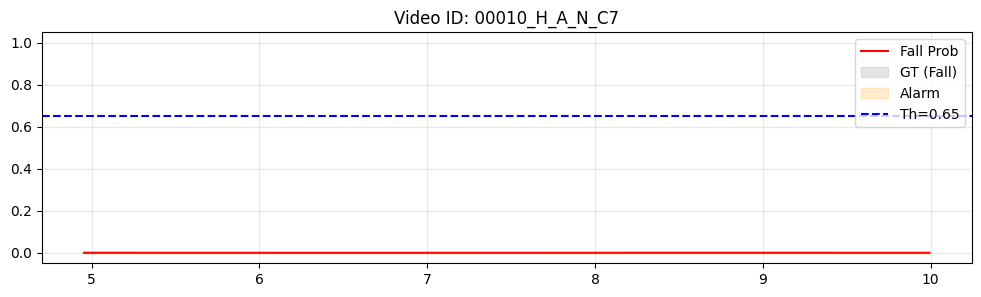

[2026-04-13 16:59:09] loading csv source from /content/drive/.shortcut-targets-by-id/1sPM3m7rEt6UUnWt9ulH3rzFYhguMJMUY/졸업 과제/Falling-Detection-Development/dataset/final_dataset.csv
[2026-04-13 17:00:04] csv rows loaded=4093620 feature_count=55


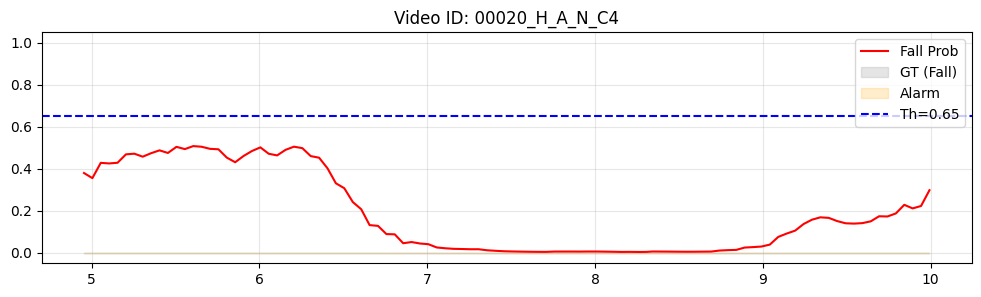

[2026-04-13 17:00:05] loading csv source from /content/drive/.shortcut-targets-by-id/1sPM3m7rEt6UUnWt9ulH3rzFYhguMJMUY/졸업 과제/Falling-Detection-Development/dataset/final_dataset.csv
[2026-04-13 17:01:02] csv rows loaded=4093620 feature_count=55


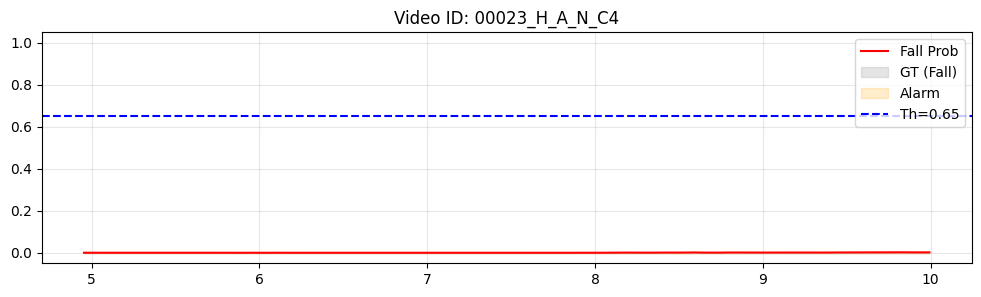

[2026-04-13 17:01:02] loading csv source from /content/drive/.shortcut-targets-by-id/1sPM3m7rEt6UUnWt9ulH3rzFYhguMJMUY/졸업 과제/Falling-Detection-Development/dataset/final_dataset.csv
[2026-04-13 17:01:58] csv rows loaded=4093620 feature_count=55


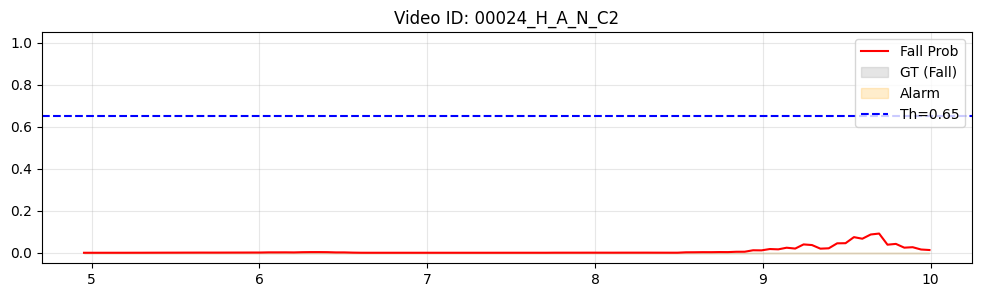

[2026-04-13 17:01:59] loading csv source from /content/drive/.shortcut-targets-by-id/1sPM3m7rEt6UUnWt9ulH3rzFYhguMJMUY/졸업 과제/Falling-Detection-Development/dataset/final_dataset.csv
[2026-04-13 17:02:56] csv rows loaded=4093620 feature_count=55


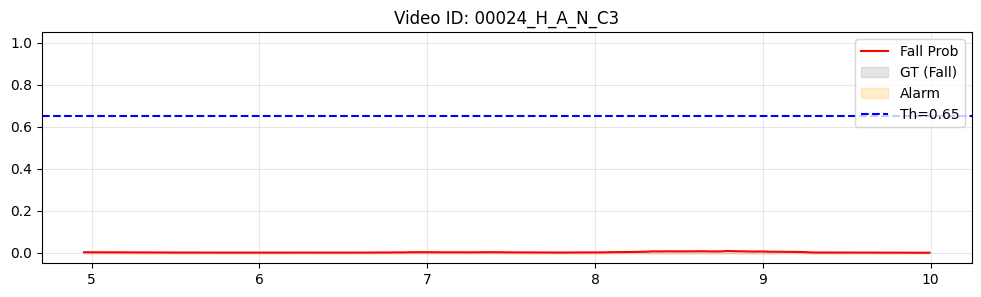

[2026-04-13 17:02:56] loading csv source from /content/drive/.shortcut-targets-by-id/1sPM3m7rEt6UUnWt9ulH3rzFYhguMJMUY/졸업 과제/Falling-Detection-Development/dataset/final_dataset.csv
[2026-04-13 17:03:52] csv rows loaded=4093620 feature_count=55


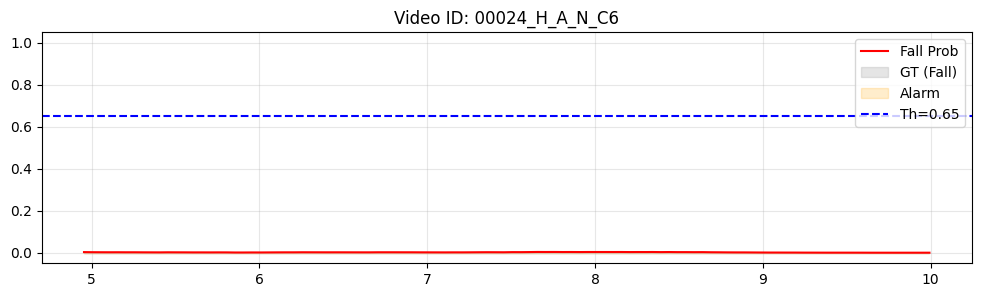

[2026-04-13 17:03:53] loading csv source from /content/drive/.shortcut-targets-by-id/1sPM3m7rEt6UUnWt9ulH3rzFYhguMJMUY/졸업 과제/Falling-Detection-Development/dataset/final_dataset.csv


KeyboardInterrupt: 

In [20]:
test_vid_df = pd.DataFrame({'video_id': g_test, 'label': y_test})
pos_vids = test_vid_df[test_vid_df['label'] == 1]['video_id'].unique()[:20]
neg_vids = test_vid_df[test_vid_df['label'] == 0]['video_id'].unique()[:20]
plot_video_probability_examples(model, config, feature_cols, mean, std, list(pos_vids) + list(neg_vids), threshold=selected_threshold)